# ⚡ Custom CUDA Transformer Inference Engine
**Project:** Zero-dependency C++ implementation of BERT/GPT-style Transformer blocks.
**Hardware:** NVIDIA Tesla T4 (Compute Capability 7.5)

---
### 🎯 Objective
To bypass the overhead of high-level frameworks (PyTorch) by manually managing GPU memory and implementing custom CUDA kernels for:
1.  **Layer Normalization**
2.  **Matrix Multiplication (Linear Projection)**
3.  **GELU Activation**

### 📊 Verification Strategy
We generate "Golden Data" using PyTorch, run the C++ Engine, and utilize Python to visualize the **Floating Point Drift** (numerical differences) between the CPU (PyTorch) and GPU (CUDA) implementations.

In [2]:
import torch
import torch.nn as nn
import struct
import numpy as np

# --- CONFIGURATION ---
BATCH_SIZE = 1
SEQ_LEN = 128   # Sequence length (Number of tokens)
HIDDEN_DIM = 768 # Standard BERT/GPT size

# --- DEFINE THE PYTORCH MODEL ---
class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln = nn.LayerNorm(HIDDEN_DIM)
        self.linear = nn.Linear(HIDDEN_DIM, HIDDEN_DIM)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.ln(x)
        x = self.linear(x)
        x = self.act(x)
        return x

# --- GENERATE DATA ---
torch.manual_seed(42)
# Check if GPU is available, otherwise use CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on {device}...")

model = TransformerBlock().to(device).eval()
input_tensor = torch.randn(BATCH_SIZE, SEQ_LEN, HIDDEN_DIM).to(device)

# Run PyTorch Inference
with torch.no_grad():
    output_tensor = model(input_tensor)

print("PyTorch Inference Complete.")
print(f"Input Shape: {input_tensor.shape}")
print(f"Output Shape: {output_tensor.shape}")
print(f"First 5 output values: {output_tensor[0,0,:5].cpu().numpy()}")

# --- EXPORT BINARY FILES (For C++ to read) ---
def write_bin(tensor, filename):
    # FIX IS HERE: Added .detach()
    data = tensor.detach().cpu().numpy().flatten().astype(np.float32)
    data.tofile(filename)
    print(f"Saved {filename} ({len(data)} floats)")

# 1. Save Input
write_bin(input_tensor, "input.bin")
# 2. Save Weights (Linear Weights + Bias + LayerNorm Weights + Bias)
write_bin(model.linear.weight.T, "weight.bin") # Transpose weight for MatMul
write_bin(model.linear.bias, "bias.bin")
write_bin(model.ln.weight, "ln_weight.bin")
write_bin(model.ln.bias, "ln_bias.bin")
# 3. Save Expected Output (To compare later)
write_bin(output_tensor, "golden_output.bin")

Running on cuda...
PyTorch Inference Complete.
Input Shape: torch.Size([1, 128, 768])
Output Shape: torch.Size([1, 128, 768])
First 5 output values: [-0.04016237 -0.16961582 -0.1691756   0.40519148 -0.15316916]
Saved input.bin (98304 floats)
Saved weight.bin (589824 floats)
Saved bias.bin (768 floats)
Saved ln_weight.bin (768 floats)
Saved ln_bias.bin (768 floats)
Saved golden_output.bin (98304 floats)


In [4]:
# we need three kernels LayerNorm, MatMul, GELU

%%writefile kernels.cu
#include <cuda_runtime.h>
#include <math.h>

// --- 1. GELU KERNEL ---
// Gaussian Error Linear Unit (Standard in LLMs)
__global__ void gelu_kernel(float* x, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        float val = x[idx];
        // Constants for GELU approximation
        const float b = 0.7978845608028654f; // sqrt(2/pi)
        const float c = 0.044715f;
        float tanh_val = tanhf(b * (val + c * val * val * val));
        x[idx] = 0.5f * val * (1.0f + tanh_val);
    }
}

// --- 2. LAYER NORM KERNEL ---
// Normalizes across the Hidden Dimension (768)
__global__ void layernorm_kernel(float* input, float* output, float* gamma, float* beta, int hidden_dim, int seq_len) {
    int row = blockIdx.x; // One block per token (sequence row)
    if (row >= seq_len) return;

    // 1. Calculate Mean
    float mean = 0.0f;
    for (int i = threadIdx.x; i < hidden_dim; i += blockDim.x) {
        mean += input[row * hidden_dim + i];
    }
    // Reduction (Simple version: specific to block size, optimized would use shared mem)
    // Note: For this tutorial, we assume blockDim.x >= hidden_dim is not guaranteed,
    // but let's stick to simple atomicAdd for clarity or simple loop if 1 thread/row (slow).
    // BETTER APPROACH for Tutorial: 1 thread computes logic for the row (Not fastest, but readable)

    // RE-WRITE for simplicity/readability:
    if (threadIdx.x == 0) {
        float sum = 0.0f;
        for(int i=0; i<hidden_dim; ++i) sum += input[row*hidden_dim + i];
        float mu = sum / hidden_dim;

        float var_sum = 0.0f;
        for(int i=0; i<hidden_dim; ++i) {
            float diff = input[row*hidden_dim + i] - mu;
            var_sum += diff * diff;
        }
        float sigma = sqrtf(var_sum / hidden_dim + 1e-5f);

        for(int i=0; i<hidden_dim; ++i) {
            output[row*hidden_dim + i] = ((input[row*hidden_dim + i] - mu) / sigma) * gamma[i] + beta[i];
        }
    }
}

// --- 3. MATRIX MULTIPLICATION KERNEL ---
// C = A * B + Bias
// A: (M x K), B: (K x N), C: (M x N)
__global__ void matmul_kernel(float* A, float* B, float* bias, float* C, int M, int N, int K) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < M && col < N) {
        float sum = 0.0f;
        for (int i = 0; i < K; ++i) {
            sum += A[row * K + i] * B[i * N + col];
        }
        // Add Bias immediately
        C[row * N + col] = sum + bias[col];
    }
}

Writing kernels.cu


In [10]:
%%writefile transformer_engine.cu
#include <iostream>
#include <fstream>
#include <vector>
#include <cuda_runtime.h>
#include <math.h>

#define cudaCheckErrors(msg) \
    do { \
        cudaError_t __err = cudaGetLastError(); \
        if (__err != cudaSuccess) { \
            fprintf(stderr, "Fatal error: %s (%s at %s:%d)\n", \
                msg, cudaGetErrorString(__err), \
                __FILE__, __LINE__); \
            exit(1); \
        } \
    } while (0)

const int BATCH = 1;
const int SEQ = 128;
const int HIDDEN = 768;
const int SIZE = BATCH * SEQ * HIDDEN;

// --- KERNELS (Same as before) ---
__global__ void gelu_kernel(float* x, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        float val = x[idx];
        const float b = 0.7978845608028654f;
        const float c = 0.044715f;
        float tanh_val = tanhf(b * (val + c * val * val * val));
        x[idx] = 0.5f * val * (1.0f + tanh_val);
    }
}

__global__ void layernorm_kernel(float* input, float* output, float* gamma, float* beta, int hidden_dim, int seq_len) {
    int row = blockIdx.x;
    if (row >= seq_len) return;
    if (threadIdx.x == 0) {
        float sum = 0.0f;
        for(int i=0; i<hidden_dim; ++i) sum += input[row*hidden_dim + i];
        float mu = sum / hidden_dim;
        float var_sum = 0.0f;
        for(int i=0; i<hidden_dim; ++i) {
            float diff = input[row*hidden_dim + i] - mu;
            var_sum += diff * diff;
        }
        float sigma = sqrtf(var_sum / hidden_dim + 1e-5f);
        for(int i=0; i<hidden_dim; ++i) {
            output[row*hidden_dim + i] = ((input[row*hidden_dim + i] - mu) / sigma) * gamma[i] + beta[i];
        }
    }
}

__global__ void matmul_kernel(float* A, float* B, float* bias, float* C, int M, int N, int K) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < M && col < N) {
        float sum = 0.0f;
        for (int i = 0; i < K; ++i) {
            sum += A[row * K + i] * B[i * N + col];
        }
        C[row * N + col] = sum + bias[col];
    }
}

// --- HELPER ---
void read_bin(const char* filename, float* data, int size) {
    std::ifstream file(filename, std::ios::binary);
    if (!file) { std::cerr << "Error opening " << filename << std::endl; exit(1); }
    file.read(reinterpret_cast<char*>(data), size * sizeof(float));
}

void write_bin(const char* filename, float* data, int size) {
    std::ofstream file(filename, std::ios::binary);
    if (!file) { std::cerr << "Error writing " << filename << std::endl; exit(1); }
    file.write(reinterpret_cast<char*>(data), size * sizeof(float));
    file.close();
}

int main() {
    std::cout << "Initializing Engine..." << std::endl;

    float* h_input = new float[SIZE];
    float* h_output = new float[SIZE];
    float* h_weights = new float[HIDDEN * HIDDEN];
    float* h_bias = new float[HIDDEN];
    float* h_ln_w = new float[HIDDEN];
    float* h_ln_b = new float[HIDDEN];
    float* h_golden = new float[SIZE];

    read_bin("input.bin", h_input, SIZE);
    read_bin("weight.bin", h_weights, HIDDEN * HIDDEN);
    read_bin("bias.bin", h_bias, HIDDEN);
    read_bin("ln_weight.bin", h_ln_w, HIDDEN);
    read_bin("ln_bias.bin", h_ln_b, HIDDEN);
    read_bin("golden_output.bin", h_golden, SIZE);

    float *d_input, *d_ln_out, *d_output, *d_weights, *d_bias, *d_ln_w, *d_ln_b;
    cudaMalloc(&d_input, SIZE * sizeof(float));
    cudaMalloc(&d_ln_out, SIZE * sizeof(float));
    cudaMalloc(&d_output, SIZE * sizeof(float));
    cudaMalloc(&d_weights, HIDDEN * HIDDEN * sizeof(float));
    cudaMalloc(&d_bias, HIDDEN * sizeof(float));
    cudaMalloc(&d_ln_w, HIDDEN * sizeof(float));
    cudaMalloc(&d_ln_b, HIDDEN * sizeof(float));
    cudaCheckErrors("Malloc");

    cudaMemcpy(d_input, h_input, SIZE * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_weights, h_weights, HIDDEN * HIDDEN * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_bias, h_bias, HIDDEN * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_ln_w, h_ln_w, HIDDEN * sizeof(float), cudaMemcpyHostToDevice);
    cudaMemcpy(d_ln_b, h_ln_b, HIDDEN * sizeof(float), cudaMemcpyHostToDevice);
    cudaCheckErrors("Memcpy H2D");

    layernorm_kernel<<<SEQ, 1>>>(d_input, d_ln_out, d_ln_w, d_ln_b, HIDDEN, SEQ);
    cudaDeviceSynchronize();

    dim3 blockDim(16, 16);
    dim3 gridDim((HIDDEN + 15) / 16, (SEQ + 15) / 16);
    matmul_kernel<<<gridDim, blockDim>>>(d_ln_out, d_weights, d_bias, d_output, SEQ, HIDDEN, HIDDEN);
    cudaDeviceSynchronize();

    int threads = 256;
    int blocks = (SIZE + threads - 1) / threads;
    gelu_kernel<<<blocks, threads>>>(d_output, SIZE);
    cudaDeviceSynchronize();

    cudaMemcpy(h_output, d_output, SIZE * sizeof(float), cudaMemcpyDeviceToHost);
    cudaCheckErrors("Memcpy D2H");

    // --- NEW: EXPORT OUTPUT FOR PYTHON VISUALIZATION ---
    std::cout << "Exporting CUDA results to 'cuda_output.bin'..." << std::endl;
    write_bin("cuda_output.bin", h_output, SIZE);

    std::cout << "Done." << std::endl;
    return 0;
}

Overwriting transformer_engine.cu


In [21]:
# # Check which GPU we actually have (Just to be sure)
# !nvidia-smi

# # Compile specifically for the T4 GPU (sm_75)
# !nvcc -arch=sm_75 transformer_engine.cu -o transformer_engine

# # Run
# !./transformer_engine

# Check which GPU we actually have (Just to be sure)
!nvidia-smi

# Compile specifically for the T4 GPU (sm_75)
!nvcc -arch=sm_75 transformer_engine.cu -o transformer_engine

# Run
!./transformer_engine

Sat Dec  6 12:18:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             33W /   70W |     152MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

✅ Data Loaded. Total floats: 98304
📉 Max Error: 0.000386
📉 Mean Error: 0.00003711


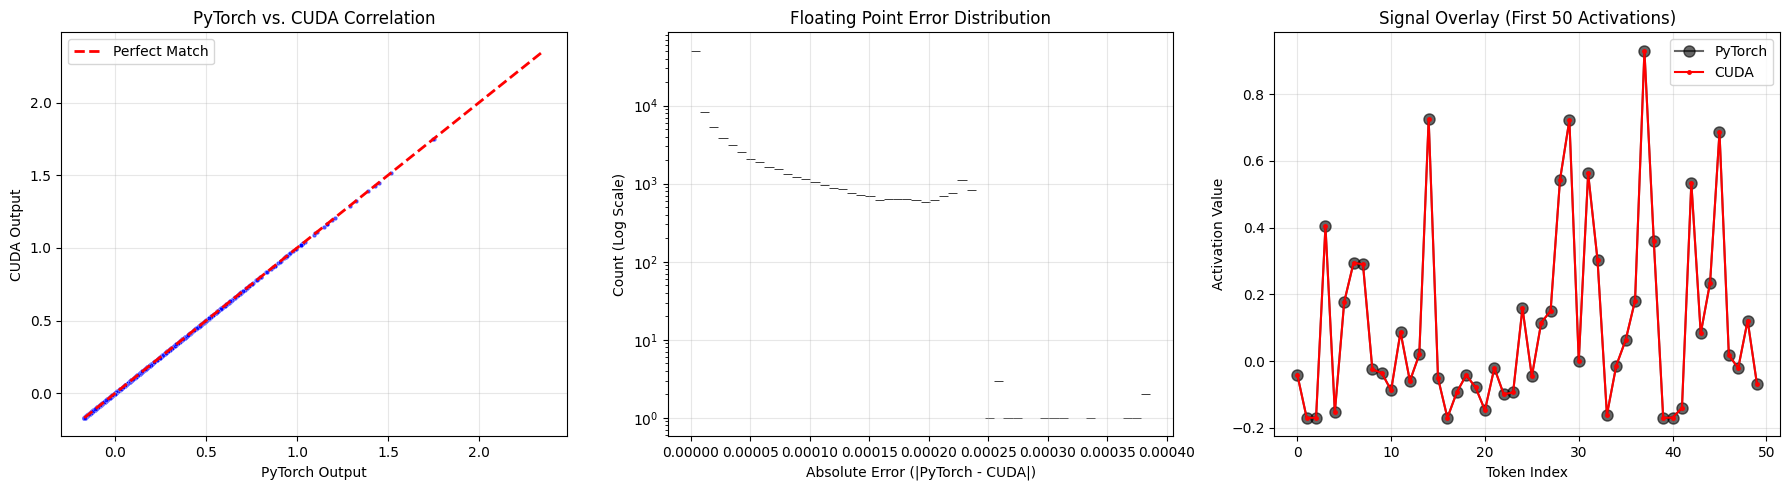

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the Binary Files
def load_bin(filename):
    return np.fromfile(filename, dtype=np.float32)

pytorch_out = load_bin("golden_output.bin")
cuda_out = load_bin("cuda_output.bin")

# Calculate Errors
abs_error = np.abs(pytorch_out - cuda_out)
max_error = np.max(abs_error)
mean_error = np.mean(abs_error)

print(f"✅ Data Loaded. Total floats: {len(pytorch_out)}")
print(f"📉 Max Error: {max_error:.6f}")
print(f"📉 Mean Error: {mean_error:.8f}")

# --- VISUALIZATION ---
plt.figure(figsize=(18, 5))

# Plot 1: Scatter Correlation (Should be a perfect diagonal line)
plt.subplot(1, 3, 1)
plt.title("PyTorch vs. CUDA Correlation")
sns.scatterplot(x=pytorch_out[:1000], y=cuda_out[:1000], s=10, alpha=0.7, color='blue')
plt.plot([min(pytorch_out), max(pytorch_out)], [min(pytorch_out), max(pytorch_out)], 'r--', lw=2, label="Perfect Match")
plt.xlabel("PyTorch Output")
plt.ylabel("CUDA Output")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Error Distribution (Should be a spike at 0)
plt.subplot(1, 3, 2)
plt.title("Floating Point Error Distribution")
sns.histplot(abs_error, bins=50, log_scale=(False, True), color='red') # Log scale y-axis to see outliers
plt.xlabel("Absolute Error (|PyTorch - CUDA|)")
plt.ylabel("Count (Log Scale)")
plt.grid(True, alpha=0.3)

# Plot 3: Signal Overlay (First 50 values)
plt.subplot(1, 3, 3)
plt.title("Signal Overlay (First 50 Activations)")
plt.plot(pytorch_out[:50], 'ko-', label='PyTorch', markersize=8, alpha=0.6)
plt.plot(cuda_out[:50], 'r.-', label='CUDA', markersize=5)
plt.xlabel("Token Index")
plt.ylabel("Activation Value")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()